<a href="https://colab.research.google.com/github/philipassadaziz-2002/fuzzy-factory-analytics/blob/main/Logistic_Regression_Fuzzy_Factory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab: Logistic Regression Algorithm

Our task is to build a Logistic Regression model to solve a binary classification problem: predict whether a website session on Maven Fuzzy Factory converts into an order, based on the session's traffic source, campaign, device, and whether the visitor is returning.

## Section 1: Importing dependencies and dataset
### Step 1: Import the required Libraries

In [5]:
import matplotlib.pyplot as plt  #import matplotlib for data visualization
import seaborn as sns #data visulaization library based on matplotlib
import numpy as np #imports a fast numerical programming library
import pandas as pd #imports panda for easy data analysis and manipulation
from sklearn.model_selection import train_test_split #import train_test_split function from model_selction module
from sklearn.preprocessing import MinMaxScaler #imports MinMaxScaler from preprocessing module for dataset standardization
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,accuracy_score

import warnings
warnings.filterwarnings("ignore") #to remove unwanted warnings

### Step 2: Load and analyse dataset

In [6]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Loading the csv files from Google Drive
sessions = pd.read_csv('/content/drive/MyDrive/raw_data/website_sessions.csv')
orders = pd.read_csv('/content/drive/MyDrive/raw_data/orders.csv')

# Build the dataset: one row per session, converted = 'Y' if the session made an order
SessionsData = sessions[['website_session_id','is_repeat_session','utm_source',
                         'utm_campaign','device_type','http_referer']].copy()
SessionsData['converted'] = np.where(
    SessionsData['website_session_id'].isin(orders['website_session_id']), 'Y', 'N')
SessionsData.head()

,website_session_id,is_repeat_session,utm_source,utm_campaign,device_type,http_referer,converted
0,1,0,gsearch,nonbrand,mobile,https://www.gsearch.com,N
1,2,0,gsearch,nonbrand,desktop,https://www.gsearch.com,N
2,3,0,gsearch,nonbrand,desktop,https://www.gsearch.com,N
3,4,0,gsearch,nonbrand,desktop,https://www.gsearch.com,N
4,5,0,gsearch,nonbrand,mobile,https://www.gsearch.com,N


In [8]:
SessionsData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   is_repeat_session   472871 non-null  int64 
 2   utm_source          389543 non-null  object
 3   utm_campaign        389543 non-null  object
 4   device_type         472871 non-null  object
 5   http_referer        432954 non-null  object
 6   converted           472871 non-null  object
dtypes: int64(2), object(5)
memory usage: 25.3+ MB


In [9]:
#use .unique() to find out the unique values of the target; returns 'Y' (converted) or 'N'
SessionsData.converted.unique()

array(['N', 'Y'], dtype=object)

In [10]:
SessionsData['converted'].value_counts().index

Index(['N', 'Y'], dtype='object', name='converted')

In [11]:
#use value_counts() to count 'Y' and 'N' sessions
SessionsData['converted'].value_counts()

,count
converted,
N,440558
Y,32313


### Step 3: Data visualization

In [12]:
Y = SessionsData[SessionsData.converted == "Y"]
Y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32313 entries, 19 to 472817
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   website_session_id  32313 non-null  int64 
 1   is_repeat_session   32313 non-null  int64 
 2   utm_source          26195 non-null  object
 3   utm_campaign        26195 non-null  object
 4   device_type         32313 non-null  object
 5   http_referer        29457 non-null  object
 6   converted           32313 non-null  object
dtypes: int64(2), object(5)
memory usage: 2.0+ MB


In [13]:
N = SessionsData[SessionsData.converted == "N"]
N.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440558 entries, 0 to 472870
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  440558 non-null  int64 
 1   is_repeat_session   440558 non-null  int64 
 2   utm_source          363348 non-null  object
 3   utm_campaign        363348 non-null  object
 4   device_type         440558 non-null  object
 5   http_referer        403497 non-null  object
 6   converted           440558 non-null  object
dtypes: int64(2), object(5)
memory usage: 26.9+ MB


### Step 4: Handling categorical data

To be able to test and train our ML model, we need to encode the classes 'Y' and 'N'. We will use Pandas to convert 'converted' to a category type. The text features (source, campaign, device, referer) are also converted into numeric dummy columns.

In [16]:
# converting type of columns to 'category'
SessionsData['converted'] = SessionsData['converted'].astype('category')
## Assigning numerical values and storing in another column
SessionsData['class'] = SessionsData['converted'].cat.codes

# Output:  [0, 0, 1, 0, ...]

print("Encoded data",SessionsData['class'], sep="\n")

Encoded data
0         0
1         0
2         0
3         0
4         0
         ..
472866    0
472867    0
472868    0
472869    0
472870    0
Name: class, Length: 472871, dtype: int8


In [17]:
#remove column 'converted' and the session id before feeding the final preprocessed data to machine learning model
SessionsData=SessionsData.drop(columns=['converted','website_session_id'],axis=1)

# fill missing text values and turn text columns into numeric dummy columns
SessionsData=SessionsData.fillna('none')
SessionsData=pd.get_dummies(SessionsData, columns=['utm_source','utm_campaign','device_type','http_referer'], dtype=int)
SessionsData.head(10)

,is_repeat_session,class,utm_source_bsearch,utm_source_gsearch,utm_source_none,utm_source_socialbook,utm_campaign_brand,utm_campaign_desktop_targeted,utm_campaign_nonbrand,utm_campaign_none,utm_campaign_pilot,device_type_desktop,device_type_mobile,http_referer_https://www.bsearch.com,http_referer_https://www.gsearch.com,http_referer_https://www.socialbook.com,http_referer_none
0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0
1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
2,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
3,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
4,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0
5,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
6,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0
7,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0
8,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0
9,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0


### Step 4: Split dataset into training and testing

In [18]:
X=SessionsData.drop('class',axis=1) #drop class column and assign the data features as X
y=SessionsData['class'] #assign class (target) as y

In [19]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=3)

In [20]:
#examine the shape for of the train and test data

print('Shape of X_train:',X_train.shape)
print('Shape of y_train:',y_train.shape)
print('Shape of X_test:',X_test.shape)
print('Shape of y_test:',y_test.shape)

Shape of X_train: (378296, 16)
Shape of y_train: (378296,)
Shape of X_test: (94575, 16)
Shape of y_test: (94575,)


### Step 5: Feature scaling

In [21]:
# Pre-process data
scaler = MinMaxScaler() # scales each feature between (0,1)
X_train = scaler.fit_transform(X_train) # Learns the min and max of each feature from the training data. scales the training data
X_test = scaler.transform(X_test) #scales the test data

In [22]:
X_train = X_train.T
y_train = y_train.to_numpy()
y_train = y_train.reshape(1, X_train.shape[1])

X_test = X_test.T
y_test = y_test.to_numpy()
y_test = y_test.reshape(1, X_test.shape[1])

print('Shape of X_train:',X_train.shape)
print('Shape of y_train:',y_train.shape)
print('Shape of X_test:',X_test.shape)
print('Shape of y_test:',y_test.shape)

Shape of X_train: (16, 378296)
Shape of y_train: (1, 378296)
Shape of X_test: (16, 94575)
Shape of y_test: (1, 94575)


## Section 2: Implementing your Logistic regression model

In [23]:
# Scikit-Learn functions implementation
Xtrain = X_train.T
Xtest = X_test.T

# Ensure y is 1D as required by scikit-learn
ytrain = y_train.ravel()

# Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)

# Train the model using the training sets
logreg.fit(Xtrain, ytrain)

# Predict the response for test dataset
y_pred = logreg.predict(Xtest)
print(y_pred)

[0 0 0 ... 0 0 0]


In [24]:
print('Accuracy on test set: ', accuracy_score(y_test.ravel(), y_pred))

Accuracy on test set:  0.9324134284959027


In [25]:
# Baseline: accuracy if we always predicted "not converted"
print('Baseline accuracy: ', 1 - y_test.mean())

Baseline accuracy:  0.9324134284959027


**Evaluate the accuracy of the Logistic regression model using a confusion matrix.**

In [26]:
#evaluate model accuracy using confusion matrix metric
cm=confusion_matrix(y_test.ravel(), y_pred)
print(cm)

[[88183     0]
 [ 6392     0]]


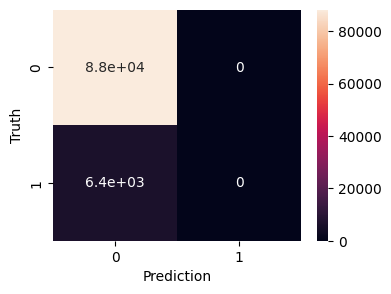

In [27]:
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True)
plt.ylabel("Truth")
plt.xlabel("Prediction")
plt.show()